In [21]:
import os
import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score
import statsmodels.api as sm

import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from dtaidistance import dtw

## Mesh Population Evaluation (Docomo Konzatsu)

In [ ]:
# real = pd.read_csv("/mnt/large/data/Konzatsu/00_納品物　東京大学様/01_静岡県＋富山県全域_総数.csv")
real = pd.read_csv("C:/Data/observation/01_静岡県＋富山県全域_総数.csv")
real['time'] = real['time'] / 100
real

In [ ]:
columns = ['area'] + [f'{h:02d}:{m:02d}' for h in range(24) for m in range(0, 60, 6)]
# pseudo = pd.read_csv("/mnt/free/owner/PseudoPFLOW/mesh_pop/22_mesh_volume4.csv", names=columns)
pseudo = pd.read_csv("C:/Data/PseudoPFLOW/mesh_volume/22/mesh_volume.csv", names=columns)
pseudo

### 500m Mesh Evaluation

In [ ]:
comparison = pd.merge(real[real['time']==6][['area', 'population']], pseudo[['area', '06:00']], on='area')
comparison['population'].corr(comparison['06:00'])

In [ ]:
comparison = pd.merge(real[real['time']==8][['area', 'population']], pseudo[['area', '08:00']], on='area')
comparison['population'].corr(comparison['08:00'])

In [ ]:
comparison = pd.merge(real[real['time']==10][['area', 'population']], pseudo[['area', '10:00']], on='area')
comparison['population'].corr(comparison['10:00'])

In [ ]:
comparison = pd.merge(real[real['time']==12][['area', 'population']], pseudo[['area', '12:00']], on='area')
comparison['population'].corr(comparison['12:00'])

In [ ]:
comparison = pd.merge(real[real['time']==14][['area', 'population']], pseudo[['area', '14:00']], on='area')
comparison['population'].corr(comparison['14:00'])

In [ ]:
comparison = pd.merge(real[real['time']==16][['area', 'population']], pseudo[['area', '16:00']], on='area')
comparison['population'].corr(comparison['16:00'])

In [ ]:
comparison = pd.merge(real[real['time']==18][['area', 'population']], pseudo[['area', '18:00']], on='area')
comparison['population'].corr(comparison['18:00'])**2

In [ ]:
comparison = pd.merge(real[real['time']==20][['area', 'population']], pseudo[['area', '20:00']], on='area')
comparison['population'].corr(comparison['20:00'])**2

In [ ]:
# 绘制散点图
plt.figure(figsize=(8, 6))
plt.scatter(comparison['population'], comparison['08:00'], alpha=0.7)
plt.title('500m Population Comparison at 8:00')
plt.xlabel('Docomo')
plt.ylabel('Pseudo')

r2 = comparison['population'].corr(comparison['08:00'])
r2_text = f"R-square = {r2:.2f}" 
plt.text(1, 14000, r2_text, fontsize=12, color='black')  

plt.grid(True)
plt.show()

### 1000m Mesh Eval

In [ ]:
real['area_1000'] = real['area'] / 10
real['area_1000'] = real['area_1000'].astype(int)
real

In [ ]:
real_1000 = (
    real.groupby(["time", "area_1000"], as_index=False)  # 分组，并保留列作为 DataFrame
    .agg(
        population=('population', 'sum')  # 汇总人口列
    ) 
)

# real_1000 = result.to_dict(orient='index')
real_1000

In [ ]:
pseudo['area_1000'] = pseudo['area'] / 10
pseudo['area_1000'] = pseudo['area_1000'].astype(int)
pseudo

In [ ]:
pseudo_1000 = pseudo.drop(columns=['area']).groupby('area_1000', as_index=False).sum()
pseudo_1000

In [ ]:
comparison = pd.merge(real_1000[real_1000['time']==6][['area_1000', 'population']], pseudo_1000[['area_1000', '06:00']], on='area_1000')
comparison['population'].corr(comparison['06:00'])**2

In [ ]:
comparison = pd.merge(real_1000[real_1000['time']==8][['area_1000', 'population']], pseudo_1000[['area_1000', '08:00']], on='area_1000')
comparison['population'].corr(comparison['08:00'])**2

In [ ]:
comparison = pd.merge(real_1000[real_1000['time']==10][['area_1000', 'population']], pseudo_1000[['area_1000', '10:00']], on='area_1000')
comparison['population'].corr(comparison['10:00'])**2

In [ ]:
comparison = pd.merge(real_1000[real_1000['time']==12][['area_1000', 'population']], pseudo_1000[['area_1000', '12:00']], on='area_1000')
comparison['population'].corr(comparison['12:00'])**2

In [ ]:
comparison = pd.merge(real_1000[real_1000['time']==14][['area_1000', 'population']], pseudo_1000[['area_1000', '14:00']], on='area_1000')
comparison['population'].corr(comparison['14:00'])**2

In [ ]:
comparison = pd.merge(real_1000[real_1000['time']==16][['area_1000', 'population']], pseudo_1000[['area_1000', '16:00']], on='area_1000')
comparison['population'].corr(comparison['16:00'])**2

In [ ]:
comparison = pd.merge(real_1000[real_1000['time']==18][['area_1000', 'population']], pseudo_1000[['area_1000', '18:00']], on='area_1000')
comparison['population'].corr(comparison['18:00'])**2

In [ ]:
comparison = pd.merge(real_1000[real_1000['time']==20][['area_1000', 'population']], pseudo_1000[['area_1000', '20:00']], on='area_1000')
comparison['population'].corr(comparison['20:00'])**2

In [ ]:
# data = {
#     'hour': [6, 8, 10, 12, 14, 16, 18, 20],
#     'ver1.2 500m grid': [0.6092434861, 0.6058120839, 0.6052301715, 0.6088710846, 0.6099999091, 0.6136392505, 0.6223433679, 0.6201797915],
#     'ver1.2 1000m grid': [0.8146296493, 0.815738477, 0.8124203255, 0.8128713868, 0.8158288861, 0.8184119112, 0.8248993936, 0.8227830442],
#     'ver2.0 500m grid': [0.6940141817, 0.6976529008, 0.6823630252, 0.6807916037, 0.6784336639, 0.7042940719, 0.7037395987, 0.6976354778],
#     'ver2.0 1000m grid': [0.8084255809, 0.8174076625, 0.8043960296, 0.8017757717, 0.7991764448, 0.8111137048, 0.8104987893, 0.8052162085],
# }

df = pd.DataFrame(data)

# 绘制折线图
plt.figure(figsize=(12, 8))

# 配色方案
import pandas as pd
import matplotlib.pyplot as plt

# 数据
data = {
    'hour': [6, 8, 10, 12, 14, 16, 18, 20],
    'ver1.2 500m grid': [0.6092434861, 0.6058120839, 0.6052301715, 0.6088710846, 0.6099999091, 0.6136392505, 0.6223433679, 0.6201797915],
    'ver1.2 1000m grid': [0.8146296493, 0.815738477, 0.8124203255, 0.8128713868, 0.8158288861, 0.8184119112, 0.8248993936, 0.8227830442],
    'ver2.0 500m grid': [0.6940141817, 0.6976529008, 0.6823630252, 0.6807916037, 0.6784336639, 0.7042940719, 0.7037395987, 0.6976354778],
    'ver2.0 1000m grid': [0.8084255809, 0.8174076625, 0.8043960296, 0.8017757717, 0.7991764448, 0.8111137048, 0.8104987893, 0.8052162085],
    'ver2.0 500m grid (National Census Night Population)': [0.7932285389494512, 0.6589391351117977, 0.5280987341686416, 0.5364944724746706, 0.5395710145019961, 0.6248640967435501, 0.7184011798537172, 0.756581917608682],
    'ver2.0 1000m grid (National Census Night Population)': [0.8368020777036027, 0.7725222008005157, 0.6863641831403551, 0.6923379752694202, 0.6927510380642513, 0.7396803197794359, 0.7934957702608304, 0.8152592890569511],

}

df = pd.DataFrame(data)

# 绘制折线图
plt.figure(figsize=(10, 6))

# 配色方案
plt.plot(df['hour'], df['ver1.2 500m grid'], label='500m - ver1.2 v.s. Mobile Phone Data', color='blue', marker='o', markersize=4, linestyle='-', linewidth=1.2)
plt.plot(df['hour'], df['ver2.0 500m grid'], label='500m - ver2.0 v.s. Mobile Phone Data', color='red', marker='o', markersize=4,linestyle='-', linewidth=1.2)
plt.plot(df['hour'], df['ver2.0 500m grid (National Census Night Population)'], label='500m - ver2.0 v.s. National Census Data (Night)', color='green', marker='o', markersize=4,linestyle='-', linewidth=1.2)
plt.plot(df['hour'], df['ver1.2 1000m grid'], label='1000m - ver1.2 v.s. Mobile Phone Data', color='blue',  marker='^', markersize=4,linestyle='--', linewidth=1.2)
plt.plot(df['hour'], df['ver2.0 1000m grid'], label='1000m - ver2.0 v.s. Mobile Phone Data', color='red',  marker='^',markersize=4,linestyle='--', linewidth=1.2)
plt.plot(df['hour'], df['ver2.0 1000m grid (National Census Night Population)'], label='1000m - ver2.0 v.s. National Census Data (Night)', color='green',  marker='^', markersize=4,linestyle='--', linewidth=1.2)

# 添加标题、标签和图例
plt.title('Comparison of ver1.2 and ver2.0 with Mobile Phone and National Census Data', fontsize=14)
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Correlation(R2)', fontsize=12)
plt.legend(title='Version and Resolution', loc='lower right')
plt.grid(alpha=0.3)
plt.ylim(0, 1)

# 显示图形
plt.show()

### 1km National Census Comparison

In [ ]:
census_1000 = gpd.read_file('/home/owner/Downloads/1km_mesh_2018_22.shp')
census_1000 = census_1000[['MESH_ID', 'PTN_2020']].rename(columns={'MESH_ID': 'area_1000'})
census_1000

In [ ]:
comparison = pd.merge(pseudo_1000[['area_1000', '06:00']], census_1000, on='area_1000')
comparison['PTN_2020'].corr(comparison['06:00'])**2

In [ ]:
comparison = pd.merge(pseudo_1000[['area_1000', '08:00']], census_1000, on='area_1000')
comparison['PTN_2020'].corr(comparison['08:00'])**2

In [ ]:
comparison = pd.merge(pseudo_1000[['area_1000', '10:00']], census_1000, on='area_1000')
comparison['PTN_2020'].corr(comparison['10:00'])**2

In [ ]:
comparison = pd.merge(pseudo_1000[['area_1000', '12:00']], census_1000, on='area_1000')
comparison['PTN_2020'].corr(comparison['12:00'])**2

In [ ]:
comparison = pd.merge(pseudo_1000[['area_1000', '14:00']], census_1000, on='area_1000')
comparison['PTN_2020'].corr(comparison['14:00'])**2

In [ ]:
comparison = pd.merge(pseudo_1000[['area_1000', '16:00']], census_1000, on='area_1000')
comparison['PTN_2020'].corr(comparison['16:00'])**2

In [ ]:
comparison = pd.merge(pseudo_1000[['area_1000', '18:00']], census_1000, on='area_1000')
comparison['PTN_2020'].corr(comparison['18:00'])**2

In [ ]:
comparison = pd.merge(pseudo_1000[['area_1000', '20:00']], census_1000, on='area_1000')
comparison['PTN_2020'].corr(comparison['20:00'])**2

### 500m National Census Comparison

In [ ]:
census_500 = gpd.read_file('/home/owner/Downloads/500m_mesh_2018_22.shp')
census_500 = census_500[['MESH_ID', 'PTN_2020']].rename(columns={'MESH_ID': 'area'})
census_500

In [ ]:
comparison = pd.merge(pseudo[['area', '06:00']], census_500, on='area')
comparison['PTN_2020'].corr(comparison['06:00'])**2

In [ ]:
comparison = pd.merge(pseudo[['area', '08:00']], census_500, on='area')
comparison['PTN_2020'].corr(comparison['08:00'])**2

In [ ]:
comparison = pd.merge(pseudo[['area', '10:00']], census_500, on='area')
comparison['PTN_2020'].corr(comparison['10:00'])**2

In [ ]:
comparison = pd.merge(pseudo[['area', '12:00']], census_500, on='area')
comparison['PTN_2020'].corr(comparison['12:00'])**2

In [ ]:
comparison = pd.merge(pseudo[['area', '14:00']], census_500, on='area')
comparison['PTN_2020'].corr(comparison['14:00'])**2

In [ ]:
comparison = pd.merge(pseudo[['area', '16:00']], census_500, on='area')
comparison['PTN_2020'].corr(comparison['16:00'])**2

In [ ]:
comparison = pd.merge(pseudo[['area', '18:00']], census_500, on='area')
comparison['PTN_2020'].corr(comparison['18:00'])**2

In [ ]:
comparison = pd.merge(pseudo[['area', '20:00']], census_500, on='area')
comparison['PTN_2020'].corr(comparison['20:00'])**2

## Link Traffic Volume Evaluation

In [ ]:
def calculate_mape(seq1, seq2):
    epsilon = 1e-10
    mape = np.mean(np.abs((seq1 - seq2) / (seq1+epsilon))) * 100
    return mape

In [ ]:
obs = pd.read_csv('/mnt/free/Shizuoka_20201001_agg.csv')
obs = obs.rename(columns={'source_x': 'longitude', 'source_y':'latitude'})
obs

In [ ]:
ppf = pd.read_csv('/mnt/free/owner/link_volume_22_multiple_pref_all_mode_v2.csv', names=obs.columns)
ppf

In [ ]:
ppf_12 = ppf[['gid', 'vol_6', 'vol_7', 'vol_8', 'vol_9', 'vol_10', 'vol_11', 'vol_12', 'vol_13', 'vol_14', 'vol_15', 'vol_16', 'vol_17', 'vol_18']]
ppf_12['sum_12'] =   ppf[['vol_6', 'vol_7', 'vol_8', 'vol_9', 'vol_10', 'vol_11', 'vol_12', 'vol_13', 'vol_14', 'vol_15', 'vol_16', 'vol_17', 'vol_18']].sum(axis=1)
ppf_12.loc['sum'] = ppf_12.sum()
ppf_12

In [ ]:
ppf_12 = ppf[['gid', 'vol_7', 'vol_8', 'vol_9', 'vol_10', 'vol_11', 'vol_12', 'vol_13', 'vol_14', 'vol_15', 'vol_16', 'vol_17', 'vol_18']]
ppf_12['sum_12'] =   ppf[['vol_7', 'vol_8', 'vol_9', 'vol_10', 'vol_11', 'vol_12', 'vol_13', 'vol_14', 'vol_15', 'vol_16', 'vol_17', 'vol_18']].sum(axis=1)
ppf_12.loc['sum'] = ppf_12.sum()
ppf_12

In [ ]:
ppf_12.to_csv('link_volume_22_multiple_pref_all_mode_v2_12h.csv', index=False)

In [ ]:
ppf_12[ppf_12['sum_12']>10]

In [ ]:
aligned_df = pd.merge(obs, ppf, on='gid',suffixes=('_obs', '_ppf'))
aligned_df

In [ ]:
aligned_df = aligned_df.drop(columns=['longitude_ppf', 'latitude_ppf']).rename(columns={'longitude_obs': 'longitude', 'latitude_obs': 'latitude'})
aligned_df

In [ ]:
correlations = []
dtw_distances = []
for _, row in aligned_df.iterrows():
    seq1 = row.filter(like='_obs').values
    seq2 = row.filter(like='_ppf').values

    corr, _ = pearsonr(seq1, seq2)
    correlations.append(corr)
    distance = dtw.distance(seq1, seq2)
    dtw_distances.append(distance)

aligned_df['correlation'] = correlations
aligned_df['dtw_distance'] = dtw_distances

mapes = []
for _, row in aligned_df.iterrows():
    seq1 = row.filter(like='_obs').values
    seq2 = row.filter(like='_ppf').values
    mape = calculate_mape(seq1, seq2)
    mapes.append(mape)

aligned_df['mape'] = mapes
    
top_5_corr = aligned_df.nlargest(5, 'correlation')
top_5_dtw = aligned_df.nsmallest(5, 'dtw_distance')
top_5_mape = aligned_df.nsmallest(5, 'mape')

def plot_time_series(df, metric_col, top_n=5, metric_name='Correlation'):
    for i, row in df.iterrows():
        gid = row['gid']
    
        seq1 = row.filter(like='_obs').values
        seq2 = row.filter(like='_ppf').values

        value = row[metric_col]

        plt.figure(figsize=(8, 4))
        plt.plot(range(24), seq1, label='Traffic Count', marker='o')
        plt.plot(range(24), seq2, label='Pseudo PeopleFlow', marker='x')
        plt.title(f'{metric_name} Top {value}: GID {gid}')
        plt.xlabel('Hour')
        plt.ylabel('Traffic Volume')
        plt.legend()
        plt.show()

plot_time_series(top_5_corr, 'correlation', metric_name='Correlation')
plot_time_series(top_5_dtw, 'dtw_distance', metric_name='DTW Distance')
plot_time_series(top_5_mape, 'mape', metric_name='MAPE')

In [ ]:
aligned_df

In [ ]:
aligned_df[aligned_df['mape']<50]['mape'].mean()

In [ ]:
top_50_mape = aligned_df.nsmallest(50, 'mape')
plot_time_series(top_50_mape, 'mape', metric_name='MAPE')

In [ ]:
df1_hourly = aligned_df.filter(like='_obs')
df2_hourly = aligned_df.filter(like='_ppf')

df1_hourly_total = df1_hourly.sum(axis=0)
df2_hourly_total = df2_hourly.sum(axis=0)

hourly_totals = pd.DataFrame({
    'hour': [f'hour_{i}' for i in range(24)],
    'df1_total': df1_hourly_total.values,
    'df2_total': df2_hourly_total.values
})

print(hourly_totals)

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(hourly_totals['hour'], hourly_totals['df1_total'], label='API Traffic Count', marker='o')
plt.plot(hourly_totals['hour'], hourly_totals['df2_total'], label='Pseudo PFLOW Total Traffic', marker='x')
plt.xticks(rotation=45)
plt.xlabel('Hour')
plt.ylabel('Total Traffic Volume')
plt.title('Hourly Total Traffic Volume Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
map_data = aligned_df[['gid', 'latitude', 'longitude'] + [f'vol_{i}_obs' for i in range(24)] + [f'vol_{i}_ppf' for i in range(5, 24)]]

def calculate_mape(row):
    epsilon = 1e-8  
    seq1 = row[[f'vol_{i}_obs' for i in range(5, 24)]].values
    seq2 = row[[f'vol_{i}_ppf' for i in range(5, 24)]].values
    mape = np.mean(np.abs((seq1 - seq2) / (seq1 + epsilon))) * 100
    return mape

# 计算每个 gid 的 MAPE
map_data['mape'] = map_data.apply(calculate_mape, axis=1)

In [ ]:
map_data[map_data['gid']==3703972]

In [ ]:
map_data[map_data['mape']<70] # ['mape'].hist()

In [ ]:
best_gid = map_data[map_data['mape']<70]['gid'].values
best_gid

In [ ]:
from glob import glob

data_path = "/mnt/free/20201001"  # 替换为你的文件路径
files = glob(os.path.join(data_path, "*.csv"))
files

def process_file(file_path):

    file_name = os.path.basename(file_path)
    mesh_code = file_name.split("_")[3]
    hour = file_name.split("_")[4].split(".")[0]

    df = pd.read_csv(file_path)
    df['mesh_code'] = mesh_code
    df['hour'] = int(hour)
    
    return df


tf = pd.concat([process_file(file) for file in files], ignore_index=True)
select_columns = ['時刻','計測地点番号','計測地点名称','2次メッシュコード','リンク区分','リンク番号','断面交通量','経度','緯度']
tf = tf[select_columns]
tf.columns = ['timestamp', 'section_id', 'section_name', 'mesh_code', 'link_cd', 'link_id', 'volume', 'longitude', 'latitude']
tf

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# 归一化 MAPE 值并生成颜色映射
norm = Normalize(vmin=map_data['mape'].min(), vmax=120)
cmap = plt.get_cmap('coolwarm')  # 使用从暖色到冷色的配色方案

# 为每个 gid 生成颜色
map_data['color'] = map_data['mape'].apply(lambda x: cmap(norm(x)))
map_data['color'] = map_data['color'].apply(lambda c: f'rgba({int(c[0]*255)}, {int(c[1]*255)}, {int(c[2]*255)}, {c[3]})')

In [ ]:
import folium
import matplotlib.pyplot as plt
from io import BytesIO
import base64

# 创建地图中心
map_center = [map_data['latitude'].mean(), map_data['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=12)

# 定义函数生成时序图
def create_timeseries_plot(row):
    hours = [f'vol_{i}' for i in range(24)]
    df1_series = row[[f'{hour}_obs' for hour in hours]].values
    df2_series = row[[f'{hour}_ppf' for hour in hours]].values

    plt.figure(figsize=(6, 3))
    plt.plot(range(24), df1_series, label='Traffic Count', marker='o')
    plt.plot(range(24), df2_series, label='Pseudo PFLOW v2', marker='x')
    plt.title(f"GID {row['gid']} Traffic Volume")
    plt.xlabel('Hour')
    plt.ylabel('Traffic Volume')
    plt.legend()
    plt.tight_layout()

    # 保存图为 Base64 编码
    buf = BytesIO()
    plt.savefig(buf, format="png")
    buf.seek(0)
    encoded = base64.b64encode(buf.read()).decode('utf-8')
    buf.close()
    plt.close()
    return f'<img src="data:image/png;base64,{encoded}"/>'

# 添加点到地图
for _, row in map_data.iterrows():
    popup_content = create_timeseries_plot(row)
    popup = folium.Popup(html=popup_content, max_width=400)
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5,  # 调整点大小
        color=row['color'],
        fill=True,
        fill_color=row['color'],
        fill_opacity=0.7,
        popup=popup
    ).add_to(m)

# 保存地图
m.save("traffic_map_with_timeseries.html")
print("地图已保存为 traffic_map_with_timeseries.html")


In [ ]:
m

## OD Volume comparison

In [ ]:
od = gpd.read_file('/home/owner/Downloads/S05-b-10_SYUTO-1-g_PersonTripODAmount.shp')
od

In [ ]:
od = od[['S05b_003', 'S05b_004', ]]

In [ ]:
od.columns

In [ ]:
target = od[(od['S05b_003']=='0012')&(od['S05b_004']=='0012')]
int(target['S05b_005']) + int(target['S05b_011']) + int(target['S05b_017']) + int(target['S05b_023']) + int(target['S05b_029'])

In [ ]:
zones = gpd.read_file('/mnt/large/data/Shapefile/zoneshape/Tokyo_zoneshape/H10東京_修正.shp')
zones

In [ ]:
zones[zones['大ゾーン']=='0012']

In [ ]:
len(zones['大ゾーン'].unique())

In [ ]:
zones = gpd.read_file('/mnt/large/data/PersonTrip/関東都市圏/第６回（H３０）/03ゾーン図/H30_gis/H30_kzone.shp')
zones

In [ ]:
zones[zones['kzone']==12]

In [ ]:
trips = pd.read_csv('/mnt/large/data/PseudoPFLOW/ver2.0/trip/13/trip_13101.csv', names=['pid', 'time', 'origin_lon', 'origin_lat', 'destn_lon', 'destn_lat', 'transport', 'puropse', 'occupation'])
trips

## Trip Evaluation

In [2]:
# root = '/mnt/large/data/PseudoPFLOW/ver2.0/trip/22/'
# root = "C:/log/one_step_t_50_beta_1.5/trip/"
# root = "C:/log/baseline(beta=2.0)/trip/"
root = "C:/Data/PseudoPFLOW/trip/22/"
shizuoka = []

for filename in os.listdir(root):
    df = pd.read_csv(root+filename, names=['pid', 'time', 'origin_lon', 'origin_lat', 'destn_lon', 'destn_lat', 'transport', 'purpose', 'occupation'])
    shizuoka.append(df)
    
shizuoka = pd.concat(shizuoka, axis=0)
shizuoka

,pid,time,origin_lon,origin_lat,destn_lon,destn_lat,transport,purpose,occupation
0,66218309,27965,138.416206,35.001436,138.379741,34.972265,3,2,21
1,66218309,73865,138.379741,34.972265,138.416206,35.001436,3,1,21
2,66218313,27473,138.410979,35.003842,138.434087,34.994009,3,2,21
3,66218315,74495,138.416206,35.001436,138.407370,35.008742,3,2,21
4,66218316,28912,138.410979,35.003842,138.375603,34.977173,3,2,21
...,...,...,...,...,...,...,...,...,...
42334,69852387,56056,137.901238,34.815303,137.932779,34.834391,3,1,13
42335,69852401,23145,137.932059,34.833128,137.859941,34.697595,3,3,15
42336,69852401,42045,137.859941,34.697595,137.932059,34.833128,3,1,15
42337,69852414,26377,137.932779,34.834391,137.939677,34.839275,1,3,11


<Axes: >

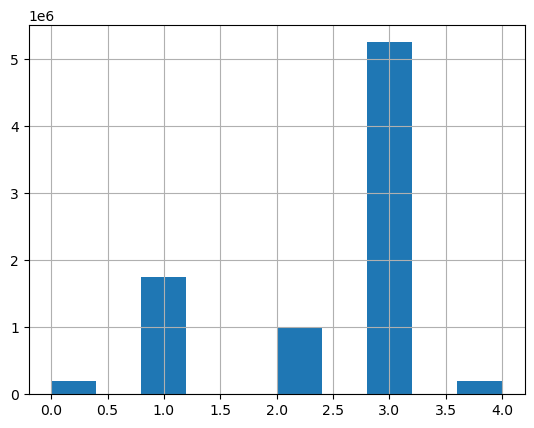

In [3]:
shizuoka['transport'].hist()

In [4]:
from math import radians, cos, sin, asin, sqrt, ceil, log

R = 6371

def haversine(lon1, lat1, lon2, lat2):
    # UNIT: KILOMETER

    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * asin(sqrt(a))

    return c * R

def distance(lat1, lon1, lat2, lon2):

    return haversine(lon1, lat1, lon2, lat2)

def df_distance(row):
    return distance(row['origin_lat'], row['origin_lon'], row['destn_lat'], row['destn_lon'])

In [5]:
shizuoka['distance'] = shizuoka.apply(df_distance, axis=1)
shizuoka

,pid,time,origin_lon,origin_lat,destn_lon,destn_lat,transport,purpose,occupation,distance
0,66218309,27965,138.416206,35.001436,138.379741,34.972265,3,2,21,4.642935
1,66218309,73865,138.379741,34.972265,138.416206,35.001436,3,1,21,4.642935
2,66218313,27473,138.410979,35.003842,138.434087,34.994009,3,2,21,2.371877
3,66218315,74495,138.416206,35.001436,138.407370,35.008742,3,2,21,1.143526
4,66218316,28912,138.410979,35.003842,138.375603,34.977173,3,2,21,4.379406
...,...,...,...,...,...,...,...,...,...,...
42334,69852387,56056,137.901238,34.815303,137.932779,34.834391,3,1,13,3.576867
42335,69852401,23145,137.932059,34.833128,137.859941,34.697595,3,3,15,16.447493
42336,69852401,42045,137.859941,34.697595,137.932059,34.833128,3,1,15,16.447493
42337,69852414,26377,137.932779,34.834391,137.939677,34.839275,1,3,11,0.831430


<Axes: >

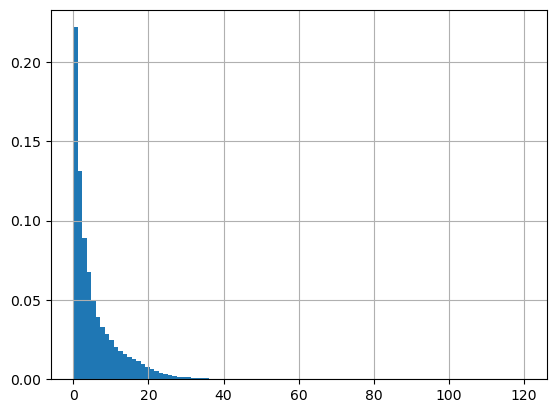

In [6]:
shizuoka['distance'].hist(density=True, bins=100)

<Axes: >

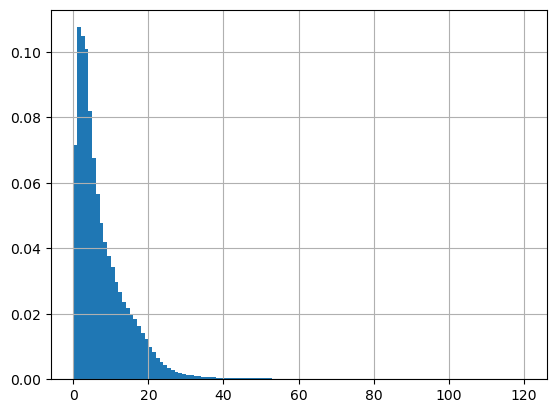

In [7]:
shizuoka[shizuoka['transport']==3]['distance'].hist(density=True, bins=120)

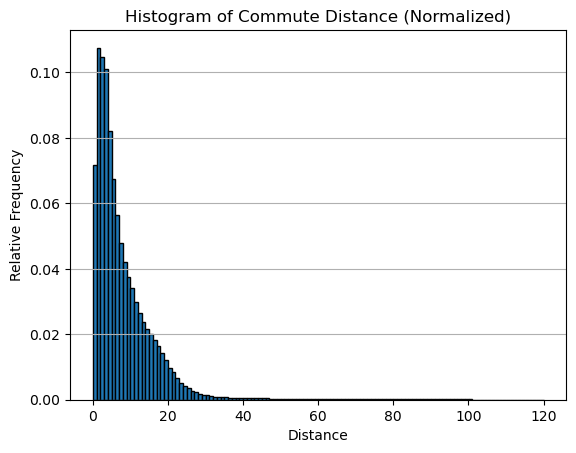

Sum of relative frequencies: 0.9999999999999999


In [8]:
counts, bins = np.histogram(shizuoka[shizuoka['transport']==3]['distance'], bins=120)
freqs = counts / counts.sum()  
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = np.diff(bins)

plt.bar(bin_centers, freqs, width=bin_width, edgecolor='black')
plt.xlabel('Distance')
plt.ylabel('Relative Frequency')
plt.title('Histogram of Commute Distance (Normalized)')
plt.grid(axis='y')
plt.show()

print("Sum of relative frequencies:", freqs.sum()) 

In [9]:
shizuoka[shizuoka['transport']==3]['distance'].mean()

8.036712723230599

<Axes: >

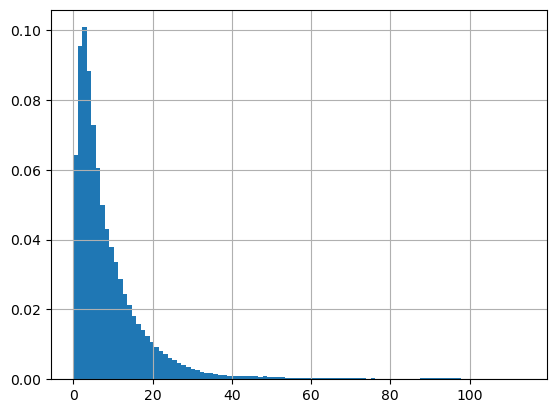

In [10]:
shizuoka[(shizuoka['purpose']==2)&(shizuoka['transport']==3)]['distance'].hist(density=True, bins=100)

In [11]:
shizuoka[(shizuoka['purpose']==2)&(shizuoka['transport']==3)]['distance'].mean()

9.482439611770713

<Axes: >

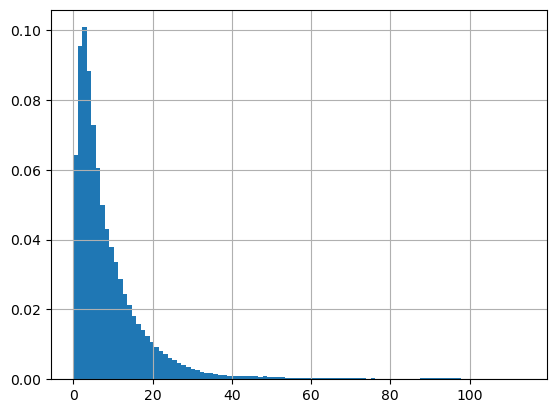

In [12]:
shizuoka[(shizuoka['purpose']==2)&(shizuoka['transport']==3)]['distance'].hist(density=True, bins=100)

In [13]:
shizuoka[(shizuoka['purpose']==3)&(shizuoka['transport']==3)]['distance'].mean()

9.904400436084439

In [14]:
shizuoka[(shizuoka['purpose']==100)&(shizuoka['transport']==3)]['distance'].mean()

6.630988709263941

In [15]:
shizuoka[(shizuoka['purpose']==200)&(shizuoka['transport']==3)]['distance'].mean()

6.367919677463201

In [16]:
shizuoka[(shizuoka['purpose']==300)&(shizuoka['transport']==3)]['distance'].mean()

6.214023497796024

In [17]:
shizuoka[(shizuoka['purpose']==400)&(shizuoka['transport']==3)]['distance'].mean()

7.127388453902875

In [18]:
shizuoka[(shizuoka['purpose']==500)&(shizuoka['transport']==3)]['distance'].mean()

7.008241462715179

In [19]:
shizuoka[(shizuoka['purpose']==1)&(shizuoka['transport']==3)]['distance'].mean()

8.377619093531537

In [20]:
shizuoka[shizuoka['purpose']==3]['distance'].min()

0.0015706739172487699

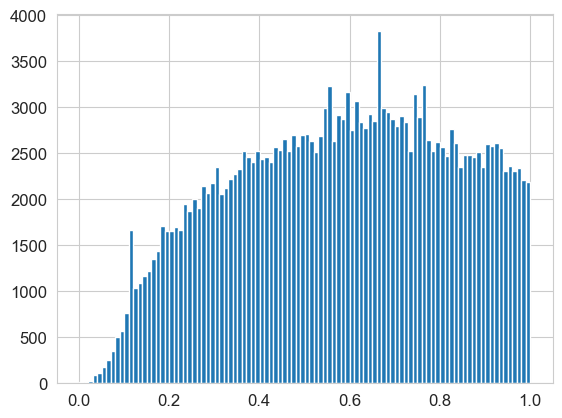

In [45]:
df = shizuoka[(shizuoka['purpose']==3)&(shizuoka['distance']<1.0)]['distance'].hist(bins=100)

<Axes: xlabel='distance', ylabel='Count'>

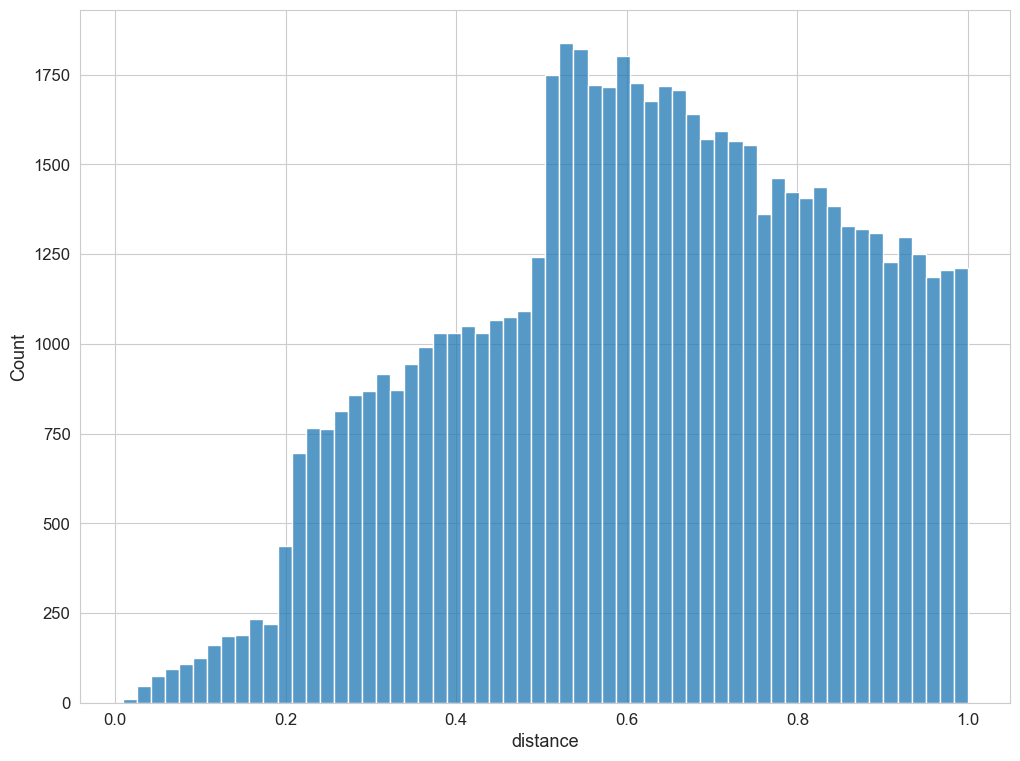

In [22]:
import seaborn as sns

# Use seaborn style for cleaner visuals
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

fig, ax1 = plt.subplots( figsize=(12, 9))

sns.histplot(data=shizuoka[(shizuoka['transport']==3)&(shizuoka['distance']<1.0)&(shizuoka['purpose']==2)]['distance'])

<Axes: xlabel='distance', ylabel='Density'>

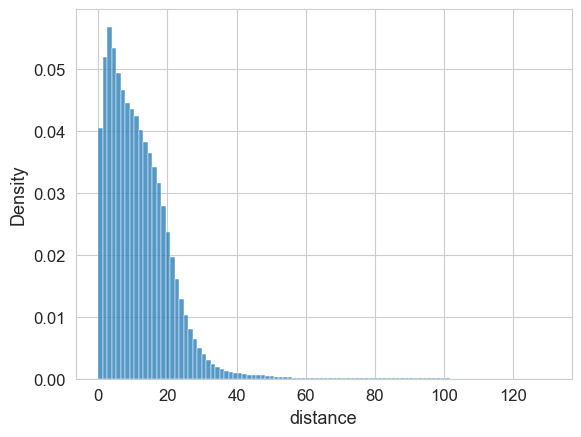

In [23]:
sns.histplot(shizuoka[shizuoka['transport']==3]['distance'], stat='density', bins=100)

In [24]:
shizuoka[(shizuoka['distance']<1)&(shizuoka['transport']==3)&(shizuoka['purpose']==2)]

,pid,time,origin_lon,origin_lat,destn_lon,destn_lat,transport,purpose,occupation,distance
16,66218326,24172,138.410979,35.003842,138.403140,35.004142,3,2,21,0.714764
32,66218337,22335,138.413371,35.003699,138.423143,35.001780,3,2,21,0.915279
40,66218354,25060,138.416206,35.001436,138.420933,35.007301,3,2,21,0.781456
49,66218375,41261,138.416206,35.001436,138.423039,35.005605,3,2,21,0.776036
51,66218375,57461,138.416206,35.001436,138.423039,35.005605,3,2,21,0.776036
...,...,...,...,...,...,...,...,...,...,...
12560,69852199,22389,137.930938,34.831071,137.924229,34.831678,3,2,21,0.616058
12567,69852210,24182,137.930126,34.829647,137.937231,34.828751,3,2,21,0.656119
12623,69852309,17023,137.929732,34.830271,137.926869,34.827174,3,2,21,0.432297
12650,69852345,24158,137.932050,34.832817,137.934434,34.825959,3,2,21,0.793013


In [25]:
shizuoka[(shizuoka['purpose']==1)&(shizuoka['transport']==3)]['distance'].mean()

11.650633437348478